# 540 — Understand every processing step

This is an original **synthetic teaching lab**, not MRI data or a clinical pipeline.
Run in a fresh Python kernel from top to bottom. Requires NumPy, SciPy, and Matplotlib;
no downloads, NiBabel, Nilearn, FSL, or fMRIPrep are required. Every code cell is at
most 20 lines. Full teaching notes and answer keys are in `../lessons/540.md`.

Before each section: predict → ask your AI to explain one small snippet → run → inspect
the deliberate error → explain what changed. The supplied code is a runnable reference,
so you can learn even when a model is unavailable. No AI API is invoked here.


In [1]:
import hashlib, json, platform
import numpy as np
import scipy
from scipy.ndimage import shift, affine_transform, gaussian_filter
from scipy.signal import butter, sosfiltfilt
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.figsize': (9, 3), 'figure.dpi': 100})
print('Versions:', np.__version__, scipy.__version__)


Versions: 2.5.3 1.18.1


## 1. Array, affine, and orientation

**Predict:** Does reversing an array axis preserve the histogram? The world positions?
The toy uses a RAS+ world convention in millimeters, but its array axis 0 runs toward
decreasing x. The display is labeled by array indices, not anatomical orientation.


In [2]:
i, j, k = np.indices((32, 40, 24))
volume = np.exp(-((i-15)**2/70 + (j-20)**2/110 + (k-12)**2/45))
volume += 0.6*np.exp(-((i-7)**2/8 + (j-25)**2/12 + (k-12)**2/8))
affine = np.array([[-2,0,0,30], [0,2,0,-40], [0,0,3,-30], [0,0,0,1.]])
point = np.array([5, 10, 4, 1])
world = (affine @ point)[:3]
print('shape:', volume.shape, 'finite fraction:', np.isfinite(volume).mean())
print('voxel spacing (mm):', np.linalg.norm(affine[:3,:3], axis=0))
print('point location (mm):', world)
assert np.allclose(world, [20,-20,-18], atol=1e-12)


shape: (32, 40, 24) finite fraction: 1.0
voxel spacing (mm): [2. 2. 3.]
point location (mm): [ 20. -20. -18.]


correct world: [ 20. -20. -18.] bad world: [-22. -20. -18.]


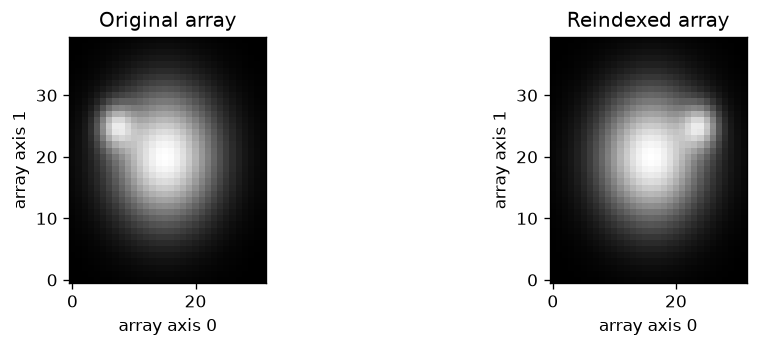

In [3]:
flipped = volume[::-1, :, :]
index_map = np.eye(4)
index_map[0,0], index_map[0,3] = -1, volume.shape[0]-1
flipped_affine = affine @ index_map
flipped_point = np.array([26,10,4,1])
correct_world = (flipped_affine @ flipped_point)[:3]
bad_world = (affine @ flipped_point)[:3]
assert np.allclose(correct_world, world, atol=1e-12)
assert np.array_equal(np.sort(volume.ravel()), np.sort(flipped.ravel()))
assert np.isclose(np.linalg.norm(bad_world-world), 42)
print('correct world:', correct_world, 'bad world:', bad_world)
fig, axes = plt.subplots(1,2)
for ax, arr, title in zip(axes, [volume,flipped], ['Original array','Reindexed array']):
    ax.imshow(arr[:,:,12].T, origin='lower', cmap='gray')
    ax.set(title=title, xlabel='array axis 0', ylabel='array axis 1')
plt.tight_layout(); plt.show()


**Interpret:** The correct representation maps corresponding values to identical physical
locations. The deliberately bad metadata moves the selected value by 42 mm while
preserving its histogram. Write why plotting a plausible silhouette cannot validate
orientation. For real NIfTI work inspect affine, header units, qform/sform, and landmarks.


## 2. Registration, resampling, and label interpolation

**Predict:** A copy moves by `(5,-3)` array samples. Which shift corrects it?
We estimate only integer translation of identical toy contrast using mean squared error.
This is not a registration method validated for brain images or different contrasts.


In [4]:
reference = np.zeros((60,60), dtype=float)
reference[18:38,22:42] = 1.0
moving = shift(reference, (5,-3), order=0, mode='constant', prefilter=False)
scores = []
for dx in range(-7,8):
    for dy in range(-7,8):
        candidate = shift(moving, (dx,dy), order=0, prefilter=False)
        scores.append((np.mean((candidate-reference)**2), dx, dy))
best_error, dx, dy = min(scores)
aligned = shift(moving, (dx,dy), order=0, prefilter=False)
bad_alignment = shift(moving, (5,-3), order=0, prefilter=False)
print('best corrective shift:', (dx,dy), 'MSE:', best_error)
print('wrong-direction MSE:', np.mean((bad_alignment-reference)**2))
assert (dx,dy) == (-5,3) and best_error < 1e-12
assert np.mean((bad_alignment-reference)**2) > 0.04


best corrective shift: (-5, 3) MSE: 0.0
wrong-direction MSE: 0.14444444444444443


nearest labels: [0. 1.]
linear values: [0.   0.25 0.5  1.  ]


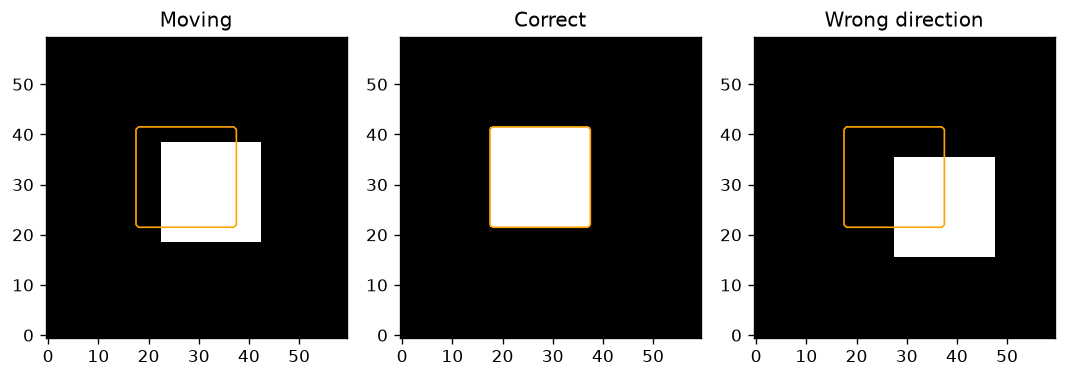

In [5]:
# Pull sampling: output[i,j] asks input[i+5,j-3] for its value.
pulled = affine_transform(moving, np.eye(2), offset=(5,-3), order=0)
assert np.array_equal(pulled, aligned)
nearest_labels = shift(reference, (0.5,0.5), order=0, prefilter=False)
linear_labels = shift(reference, (0.5,0.5), order=1, prefilter=False)
assert set(np.unique(nearest_labels)) <= {0.0,1.0}
assert np.any((linear_labels > 0) & (linear_labels < 1))
print('nearest labels:', np.unique(nearest_labels))
print('linear values:', np.unique(linear_labels))
fig, axes = plt.subplots(1,3)
for ax, arr, title in zip(axes, [moving,aligned,bad_alignment],
                         ['Moving','Correct','Wrong direction']):
    ax.imshow(arr.T, origin='lower', vmin=0, vmax=1, cmap='gray')
    ax.contour(reference.T, levels=[0.5], colors=['orange'], linewidths=1)
    ax.set_title(title)
plt.tight_layout(); plt.show()


**Interpret:** The shift operation uses the corrective displacement, while the pull sampler
uses an output-to-input lookup. More output samples are not more acquired detail.
The fractional values from linear interpolation can represent mixed intensities, but
are not new categorical tissue labels. Even nearest-neighbor label resampling can alter
region volume. On real data inspect overlays in multiple planes and retain mapping history.


## 3. Smoothing: FWHM in mm → sigma in voxels

**Predict:** Does a 6 mm kernel cover equal numbers of samples when voxel spacing differs?
Our isolated impulse is far from the array boundary; mass preservation is a check on
this configuration, not a promise for every mask or boundary policy.


In [6]:
impulse = np.zeros((65,65,65), dtype=float)
impulse[32,32,32] = 1
spacing = np.array([2.,2.,4.])
fwhm_mm = 6.0
sigma_vox = fwhm_mm / np.sqrt(8*np.log(2)) / spacing
smoothed = gaussian_filter(impulse, sigma_vox, mode='constant')
bad_smoothing = gaussian_filter(impulse, 6, mode='constant')
print('correct sigma (vox):', sigma_vox)
print('wrong physical FWHM (mm):', 6*np.sqrt(8*np.log(2))*spacing)
print('sums:', impulse.sum(), smoothed.sum(), 'peaks:', smoothed.max(), bad_smoothing.max())
assert np.allclose(np.round(sigma_vox,3), [1.274,1.274,0.637])
assert abs(smoothed.sum()-1) < 1e-10
assert 0 < bad_smoothing.max() < smoothed.max() < 1


correct sigma (vox): [1.274 1.274 0.637]
wrong physical FWHM (mm): [28.2578 28.2578 56.5157]
sums: 1.0 1.0000000000000004 peaks: 0.06137471408583081 0.00029399038312949704


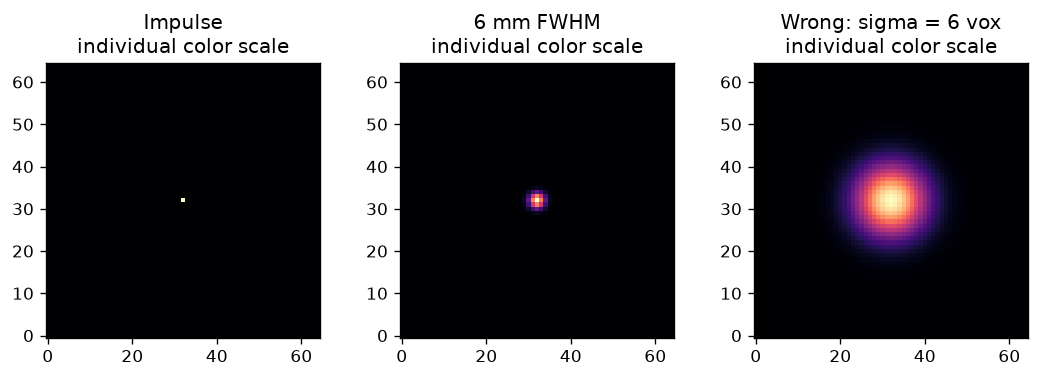

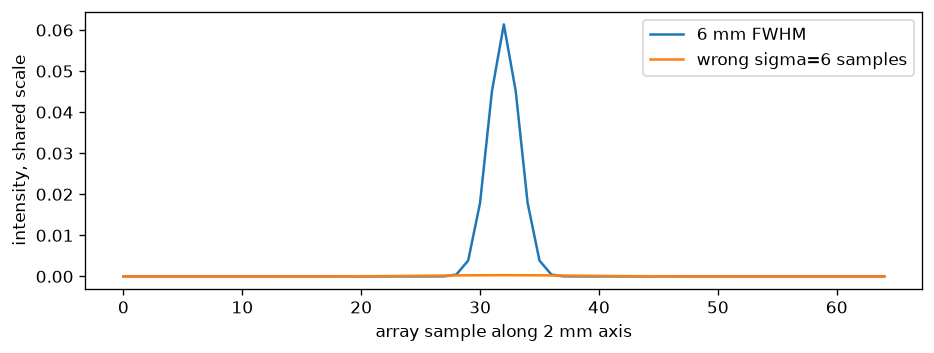

In [7]:
fig, axes = plt.subplots(1,3)
for ax, arr, title in zip(axes, [impulse,smoothed,bad_smoothing],
                         ['Impulse','6 mm FWHM','Wrong: sigma = 6 vox']):
    ax.imshow(arr[:,:,32].T, origin='lower', cmap='magma', vmin=0,
              vmax=max(arr.max(),1e-12))
    ax.set_title(title + '\nindividual color scale')
plt.tight_layout(); plt.show()
plt.plot(smoothed[:,32,32], label='6 mm FWHM')
plt.plot(bad_smoothing[:,32,32], label='wrong sigma=6 samples')
plt.xlabel('array sample along 2 mm axis'); plt.ylabel('intensity, shared scale')
plt.legend(); plt.show()


**Interpret:** In your caption distinguish additional kernel smoothness from final effective
image smoothness. Explain the lower peak, redistributed values, and possible mixing
across tissue boundaries. The slice panels use independent scales; the profile uses a
shared numerical scale so visual contrast cannot hide the amplitude change.


## 4. Temporal filtering and TR

**Predict:** With TR 2 seconds, compute the sampling frequency and Nyquist frequency.
The signal components and nuisance labels are known because these signals are synthetic.
The demonstration band is illustrative, not a universal choice for fMRI.


In [8]:
tr = 2.0
time = np.arange(300)*tr
drift = 2*np.sin(2*np.pi*0.005*time)
interest = np.sin(2*np.pi*0.05*time)
fast = 0.5*np.sin(2*np.pi*0.18*time)
raw_signal = drift + interest + fast
sos = butter(4, [0.01,0.10], btype='bandpass', fs=1/tr, output='sos')
filtered_signal = sosfiltfilt(sos, raw_signal)
wrong_sos = butter(4, [0.01,0.10], btype='bandpass', fs=1.0, output='sos')
bad_filtered = sosfiltfilt(wrong_sos, raw_signal)
print('sampling frequency, Nyquist (Hz):', 1/tr, 1/(2*tr))
assert 1/(2*tr) == 0.25


sampling frequency, Nyquist (Hz): 0.5 0.25


correct amplitudes: drift, interest, fast: [np.float64(0.008823191580960163), np.float64(0.9989885150066963), np.float64(0.00032293325354604524)]
wrong-TR interest amplitude: 0.5077001507172437


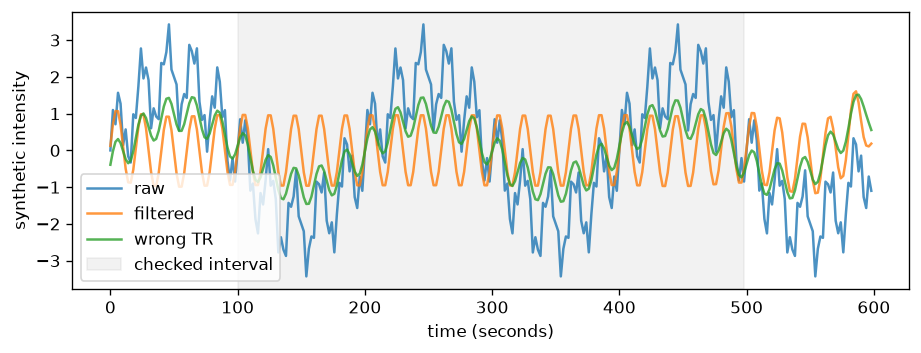

In [9]:
middle = slice(50,-50)
def amplitude_at(values, frequency):
    phase = 2*np.pi*frequency*time[middle]
    basis = np.column_stack([np.sin(phase), np.cos(phase), np.ones(len(phase))])
    coefs = np.linalg.lstsq(basis, values[middle], rcond=None)[0]
    return np.linalg.norm(coefs[:2])
amplitudes = [amplitude_at(filtered_signal, f) for f in [0.005,0.05,0.18]]
bad_interest_amp = amplitude_at(bad_filtered, 0.05)
print('correct amplitudes: drift, interest, fast:', amplitudes)
print('wrong-TR interest amplitude:', bad_interest_amp)
assert amplitudes[0] < 0.10 and amplitudes[1] > 0.90 and amplitudes[2] < 0.03
assert bad_interest_amp < 0.65
for values, label in [(raw_signal,'raw'),(filtered_signal,'filtered'),(bad_filtered,'wrong TR')]:
    plt.plot(time, values, label=label, alpha=0.8)
plt.axvspan(time[50],time[-51],color='gray',alpha=0.1,label='checked interval')
plt.xlabel('time (seconds)'); plt.ylabel('synthetic intensity'); plt.legend(); plt.show()


**Interpret:** Report the retained amplitude with its frequency. Describe why the central
interval was checked, and inspect the ends rather than claiming they are artifact-free.
Do not filter a compressed sequence of retained frames as though censoring left regular
sampling intact. Forward-backward filtering is an offline operation using future values.


## 5. Nuisance regression and incompatible filtering

**Predict:** Can fitting an unfiltered confound after filtering data reintroduce drift?
Here filtering is an exact projection away from one known slow basis, not a Butterworth
implementation. This makes the interaction visible without boundary complications.


In [10]:
d = np.sin(2*np.pi*0.005*time)
q = np.sin(2*np.pi*0.05*time)
s = np.sin(2*np.pi*0.08*time)
c = d + q
y = 3*d + 2*q + s
drift_design = np.column_stack([np.ones(len(time)), d])
def residualize(values, design):
    return values - design @ np.linalg.lstsq(design, values, rcond=None)[0]
filtered_y = residualize(y, drift_design)
filtered_c = residualize(c, drift_design)
bad_design = np.column_stack([np.ones(len(time)), c])
good_design = np.column_stack([np.ones(len(time)), filtered_c])
bad_residual = residualize(filtered_y, bad_design)
good_residual = residualize(filtered_y, good_design)
joint_design = np.column_stack([np.ones(len(time)), d, c])
joint_residual = residualize(y, joint_design)


bad/good drift projection: -0.999999999999999 8.392360880312326e-16
largest design dot product: 1.3744561044859438e-13
joint rank / algebraic residual dimension: 3 297


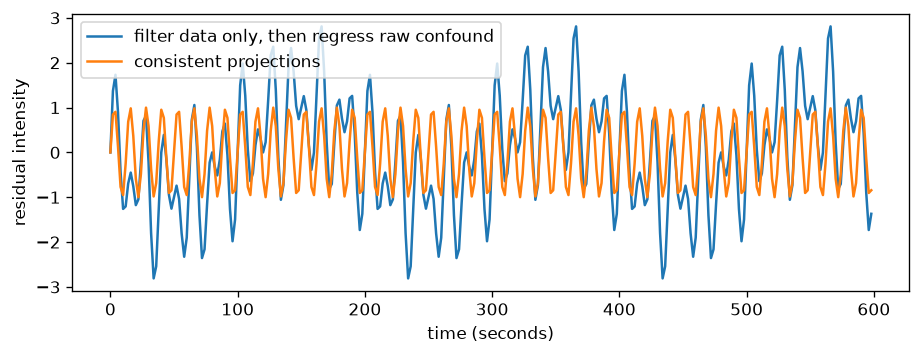

In [11]:
bad_drift = np.dot(d,bad_residual)/np.dot(d,d)
good_drift = np.dot(d,good_residual)/np.dot(d,d)
orthogonality = np.max(np.abs(good_design.T @ good_residual))
rank = np.linalg.matrix_rank(joint_design)
print('bad/good drift projection:', bad_drift,good_drift)
print('largest design dot product:', orthogonality)
print('joint rank / algebraic residual dimension:', rank,len(time)-rank)
assert np.allclose(good_residual,s,atol=1e-10)
assert np.allclose(joint_residual,good_residual,atol=1e-10)
assert np.isclose(bad_drift,-1) and abs(good_drift) < 1e-10
assert orthogonality < 1e-9 and rank == 3
plt.plot(time,bad_residual,label='filter data only, then regress raw confound')
plt.plot(time,good_residual,label='consistent projections')
plt.xlabel('time (seconds)'); plt.ylabel('residual intensity'); plt.legend(); plt.show()


**Interpret:** The good residual has the expected algebraic properties. It does not prove
a real confound specification is adequate. If `q` were the biological effect, the same
correct code would remove it. The rank-based residual dimension 297 is not the effective
degrees of freedom for inferential tests on correlated, filtered fMRI.


## 6. Provenance and a real report

**Predict:** Does an unchanged checksum establish scientific validity?
The following manifest records this synthetic exercise. It does not claim to be a full
BIDS derivative description. Retain software environment and code with actual research.


In [12]:
def array_sha256(array):
    header = json.dumps({'shape':array.shape,'dtype':str(array.dtype)},sort_keys=True)
    return hashlib.sha256(header.encode() + np.ascontiguousarray(array).tobytes()).hexdigest()
manifest = {
    'data_kind':'synthetic teaching arrays; not MRI; fMRIPrep not run',
    'versions':{'python':platform.python_version(),'numpy':np.__version__,'scipy':scipy.__version__},
    'spatial':{'input_hash':array_sha256(impulse),'output_hash':array_sha256(smoothed),
               'shape':list(impulse.shape),'dtype':str(impulse.dtype),'voxel_mm':spacing.tolist(),
               'smoothing_fwhm_mm':fwhm_mm,'sigma_vox':sigma_vox.tolist(),'boundary':'constant zero'},
    'temporal':{'tr_seconds':tr,'filter_hz':[0.01,0.10],'method':'butter N=4, sosfiltfilt',
                'input_hash':array_sha256(raw_signal),'output_hash':array_sha256(filtered_signal)},
    'regression':{'example':'separate exact-projection demonstration',
                  'method':'joint OLS: intercept, known slow basis, known confound','rank':int(rank)},
    'qc':'numeric assertions in sections 1–6; human interpretation required'}
print(json.dumps(manifest,indent=2))


{
  "data_kind": "synthetic teaching arrays; not MRI; fMRIPrep not run",
  "versions": {
    "python": "3.12.14",
    "numpy": "2.5.3",
    "scipy": "1.18.1"
  },
  "spatial": {
    "input_hash": "859ab6918a0a19c04b190ca896c1f6c30e63739a5fc2afd3a2913bfd45da71b9",
    "output_hash": "795990f485691729c53d8607cdfcdb8ba2f82cc26bcac0f600a176ded4dcf762",
    "shape": [
      65,
      65,
      65
    ],
    "dtype": "float64",
    "voxel_mm": [
      2.0,
      2.0,
      4.0
    ],
    "smoothing_fwhm_mm": 6.0,
    "sigma_vox": [
      1.2739827004320285,
      1.2739827004320285,
      0.6369913502160143
    ],
    "boundary": "constant zero"
  },
  "temporal": {
    "tr_seconds": 2.0,
    "filter_hz": [
      0.01,
      0.1
    ],
    "method": "butter N=4, sosfiltfilt",
    "input_hash": "7523f35d9d6ab7f6ed2ee9a6a3640c824006006af0eb1cb0e78fe5b3424af67b",
    "output_hash": "559334b35545a2a9fbf18c960c1e57a3e96422133ab1d6c5a44de6c6c424301c"
  },
  "regression": {
    "example": "separate

In [13]:
changed_input = impulse.copy()
changed_input[32,32,32] += 0.01
assert array_sha256(impulse) == array_sha256(impulse.copy())
assert array_sha256(impulse) != array_sha256(changed_input)
assert manifest['spatial']['input_hash'] != manifest['spatial']['output_hash']
assert manifest['spatial']['smoothing_fwhm_mm'] == 6
assert manifest['temporal']['tr_seconds'] == 2
assert 'synthetic' in manifest['data_kind']
print('All synthetic processing checks passed. No real MRI pipeline was executed.')


All synthetic processing checks passed. No real MRI pipeline was executed.


### Real-data bridge: inspect the public fMRIPrep sample report

This human exercise uses a network link; the executable core above stays fully offline.
Open the [official sample report](https://fmriprep.org/en/stable/_static/SampleReport/sample_report.html).
It is an older demonstration (20.2.3), not a current installation recommendation.

1. In the first functional-run summary find TR, non-steady-state count, and distortion
   correction status. Expected metadata: 2 seconds, one volume, no susceptibility correction.
2. Open brain-mask, functional/anatomical alignment, and BOLD-summary figures. If the
   embedded image fails, try its figure link. A missing figure is **not assessable**, never a pass.
3. Write one specific visible boundary and a location you cannot confidently judge.
   Relate a motion-trace peak to the carpet plot without claiming it proves causation.
4. Record the missing phase-encoding information and explain why an AI cannot infer its
   correct value from a successful pipeline status.
5. Draft a three-sentence QC decision naming the evidence, its limits, and the next check.

Textual metadata were verified while authoring these materials. This package neither
runs fMRIPrep nor supplies a finished visual QC verdict for the sample participant.
A confounds file lists candidate regressors; it does not establish they have been removed.

**Submission template:** question / operation and units / prediction / check and observed
result / deliberate failure / unresolved limitation. Source links and syllabus-search
outcomes are in `../sources/540.md`.


<!-- agentic-guide -->
## Agentic Deliverable Supervision (NIIN 540 · Neuroimaging Preprocessing, Registration, Surfaces, Denoising & Diffusion · macOS Goose + Ollama: Qwen & Gemma)

**Deliverable focus:** Voxel-to-world affines, pull resampling, Jacobian topology & modulation, N4 bias correction, geodesic vs. volumetric smoothing, DCT + nuisance projection, and B-vector reorientation (`PP01–PP09`, `PR01–PR21`)

### 1. Suggestive Prompt (in the spirit of what to ask — adapt, do not copy verbatim)
> Ask Goose (`Qwen`) to run and inspect the Lab 540 preprocessing pipeline—verifying RAS+ affine composition, single-step pull resampling vs. multi-step cascading blur, Jacobian determinant folding checks ($\det(J) \le 0$), simultaneous DCT + motion regression vs. sequential filtering, and polar-decomposition b-vector rotation. Ask `Gemma 4` to audit every coordinate frame, interpolation order (`order=0` for masks), and spectral degree-of-freedom ledger.

### 2. What to Look For & How to Trace the Error Back Down
- **Immediate Red Flag:** Forward-splatting leaves black grid holes, linear interpolation on integer atlas labels creates phantom intermediate ROI IDs, sequential high-pass filtering after nuisance regression re-introduces stopband motion variance, or unrotated b-vectors tilt principal diffusion eigenvectors ($V_1$) by the head rotation angle.
- **Where the Bug Entered:** Forward rounding skips target grid locations, linear interpolation averages nominal integer codes across region borders, sequential filtering projects nuisance vectors that still contain stopband drift, and head rotation changes diffusion gradient coordinates relative to the anatomy.
- **How to Fix It:** Map target coordinates backward via $T^{-1}$ pull resampling, enforce `order=0` on discrete masks/atlases, project drift and nuisance regressors simultaneously via $I - Z(Z^\top Z)^+ Z^\top$, and rotate unit gradients by the polar rotation factor $R = A(A^\top A)^{-1/2}$ of the rigid/affine transform.

### 3. Expected Outcome Range & Why It Must Look That Way
**Expected Range:** Across Lab 540, single-step composed resampling preserves high-frequency tissue boundaries, diffeomorphic warps maintain **0 folding voxels** ($\min \det(J) > 0$) while Jacobian modulation preserves total tissue volume within **< 1%**, simultaneous nuisance+DCT projection leaves **0.00 stopband leakage**, and polar b-vector reorientation reduces $V_1$ angular error to **$0.0^\circ$**. **Why:** Spatial and temporal preprocessing operators are geometric and linear-algebraic transformations that must preserve manifold topology, label discreteness, subspace orthogonality, and directional reference frames.
<!-- /agentic-guide -->
